# Load modules

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

# Define directories

In [3]:
path_current = os.getcwd()
path_data = !ls {os.path.join(path_current, 'Figure_optimization/')}

# Find monthly values for both N$_0^2$ and c

In [68]:
month_label=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
mean_list = np.zeros([3,12])
median_list = np.zeros([3,12])
for m in range(12):
    filename=path_data+month_label[m]+'.nc'
    ds = xr.open_dataset(filename)
    mean_list[0,m]=ds.N2.mean()
    median_list[0,m]=ds.N2.median()
    mean_list[1,m]=ds.cc.mean()
    median_list[1,m]=ds.cc.median()
    mean_list[2,m] = np.mean(ds.cc/np.sqrt(ds.N2))
    median_list[2,m] = np.median(ds.cc/np.sqrt(ds.N2))

# Find seasonal values for both N$_0^2$ and c

In [69]:
month_season=['Dec','Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
mean_list_season = np.zeros([3,4])
median_list_season = np.zeros([3,4])
for s in range(4):
    list_month_season=month_season[s*3:(s+1)*3]
    print(list_month_season)
    N2_list = np.zeros(10*3)
    cc_list = np.zeros(10*3)
    for m in range(3):
        filename=path_data+list_month_season[m]+'.nc'
        ds = xr.open_dataset(filename)
        N2_list[m*10:(m+1)*10] = ds.N2
        cc_list[m*10:(m+1)*10] = ds.cc
    mean_list_season[0,s]=np.mean(N2_list)
    median_list_season[0,s]=np.median(N2_list)
    mean_list_season[1,s]=np.mean(cc_list)
    median_list_season[1,s]=np.median(cc_list)
    mean_list_season[2,s] = np.mean(cc_list/np.sqrt(N2_list))
    median_list_season[2,s] = np.median(cc_list/np.sqrt(N2_list))

['Dec', 'Jan', 'Feb']
['Mar', 'Apr', 'May']
['Jun', 'Jul', 'Aug']
['Sep', 'Oct', 'Nov']


# Plot timeseries

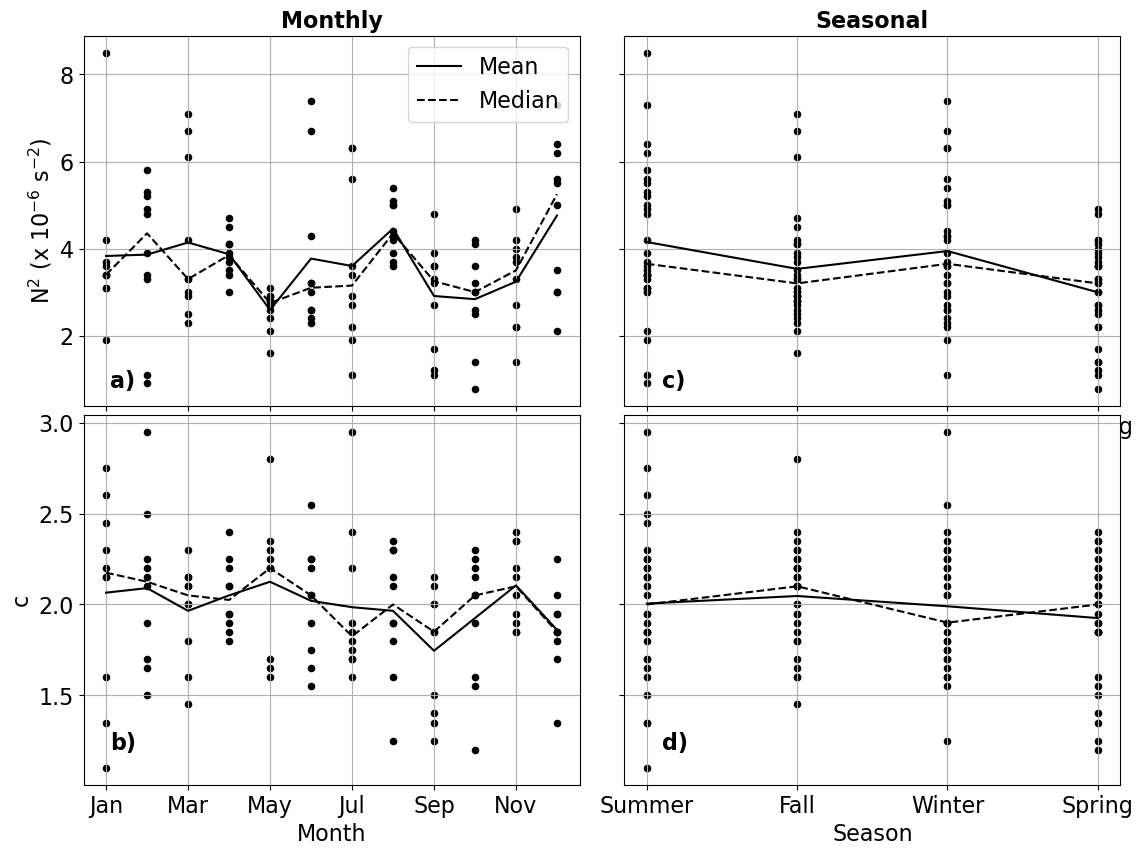

In [80]:
ft=16
fig = plt.figure()

    #Monthly N^2
plt.plot(np.arange(12), mean_list[0,:]*1e6, 'k', label='Mean')
plt.plot(np.arange(12), median_list[0,:]*1e6, 'k--', label='Median')
for m in range(12):
    filename=path_data+month_label[m]+'.nc'
    ds = xr.open_dataset(filename)
    plt.scatter(np.ones(10)*m, ds.N2*1e6, 20, 'k')
    
plt.ylabel('N$^2$ (x 10$^{-6}$ s$^{-2}$)', fontsize=ft)
plt.xlabel('Months', fontsize=ft)
plt.grid()
plt.xticks(np.arange(0,12,2), ['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov'], fontsize=ft)
plt.tick_params(axis='both',labelsize=ft)
plt.title('Monthly', fontsize=ft, fontweight='semibold')
plt.legend(fontsize=ft)
plt.text(0.1, 0.8, 'a)', fontsize=ft, fontweight='semibold')

    #Monthly c
pos0 = plt.gca().get_position()
ax1 = fig.add_axes([pos0.x0, pos0.y0-pos0.height-.02, pos0.width, pos0.height])
ax1.plot(np.arange(12), mean_list[1,:], 'k')
ax1.plot(np.arange(12), median_list[1,:], 'k--')
for m in range(12):
    filename=path_data++month_label[m]+'.nc'
    ds = xr.open_dataset(filename)
    ax1.scatter(np.ones(10)*m, ds.cc, 20, 'k')
    
plt.ylabel('c', fontsize=ft)
plt.xlabel('Month', fontsize=ft)
plt.grid()
plt.xticks(np.arange(0,12,2), ['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov'], fontsize=ft)
plt.tick_params(axis='both',labelsize=ft)
plt.text(0.1, 1.2, 'b)', fontsize=ft, fontweight='semibold')

    #Seasonal N^2
ax2 = fig.add_axes([pos0.x0+pos0.width+.07, pos0.y0, pos0.width, pos0.height])
ax2.plot(np.arange(4), mean_list_season[0,:]*1e6, 'k')
ax2.plot(np.arange(4), median_list_season[0,:]*1e6, 'k--')
for s in range(4):
    list_month_season=month_season[s*3:(s+1)*3]
    list_month_season
    N2_list = np.zeros(10*3)
    cc_list = np.zeros(10*3)
    for m in range(3):
        filename=path_data+list_month_season[m]+'.nc'
        ds = xr.open_dataset(filename)
        N2_list[m*10:(m+1)*10] = ds.N2
    ax2.scatter(np.ones(30)*s, N2_list*1e6, 20, 'k')
plt.grid()
ax2.set_yticklabels([])
plt.xticks(np.arange(4), ['S', 'Fall', 'Winter', 'Spring'])
plt.title('Seasonal', fontsize=ft, fontweight='semibold')
plt.tick_params(axis='both',labelsize=ft)
plt.text(0.1, 0.8, 'c)', fontsize=ft, fontweight='semibold')

     #Seasonal c
pos2 = ax2.get_position()
ax3 = fig.add_axes([pos2.x0, pos2.y0-pos2.height-.02, pos2.width, pos2.height])
ax3.plot(np.arange(4), mean_list_season[1,:], 'k')
ax3.plot(np.arange(4), median_list_season[1,:], 'k--')
for s in range(4):
    list_month_season=month_season[s*3:(s+1)*3]
    list_month_season
    cc_list = np.zeros(10*3)
    for m in range(3):
        filename=path_data+list_month_season[m]+'.nc'
        ds = xr.open_dataset(filename)
        cc_list[m*10:(m+1)*10] = ds.cc
    plt.scatter(np.ones(30)*s, cc_list, 20, 'k')

ax3.set_yticklabels([])
plt.xlabel('Season', fontsize=ft)
plt.grid()
plt.xticks(np.arange(4), ['Summer', 'Fall', 'Winter', 'Spring'], fontsize=ft)
plt.tick_params(axis='both',labelsize=ft)
plt.text(0.1, 1.2, 'd)', fontsize=ft, fontweight='semibold')

fig.savefig(path_data+'Timeseries_N2_and_c.png',bbox_inches='tight',dpi=300)

# Find average value for both N$_0^2$ and c

In [65]:
var_list = np.zeros([2,12*10])
for m in range(12):
    filename=path_data+month_label[m]+'.nc'
    ds = xr.open_dataset(filename)
    var_list[0,m*10:(m+1)*10]=ds.N2
    var_list[1,m*10:(m+1)*10]=ds.cc
print('N^2 = ' + str(np.round(np.median(var_list[0,:]*1e7))/10) + u' \u00B1 ' + str(np.round(np.std(var_list[0,:])*1e7)/10) + ' s^-2')
print('c = ' + str(np.round(np.median(var_list[1,:]*10))/10) + u' \u00B1 ' + str(np.round(np.std(var_list[1,:])*10)/10) + ' s^-2')

N^2 = 3.4 ± 1.5 s^-2
c = 2.0 ± 0.3 s^-2
